# Affinity Propagation (AP)

### ¿Qué es?

* Es un algoritmo de clustering `no supervisado` que, a diferencia de `K-Means` o `DBSCAN`, no necesita que le indiques el número de clusters de antemano.
* Fue propuesto por Brendan Frey y Delbert Dueck en 2007.
* En lugar de elegir aleatoriamente centroides o basarse en densidad, `Affinity Propagation` trabaja mediante el `intercambio de “mensajes”` entre puntos de datos para `decidir cuáles serán los exemplars` (ejemplares o `representativos de cada cluster`).

* ***Ventajas***
  - No requiere elegir K (el número de clusters se determina automáticamente).
  - Encuentra clusters con formas más flexibles que K-Means.
  - Identifica puntos representativos (exemplars) de manera explícita.
* ***Desventajas***
  - Puede ser más costoso computacionalmente que K-Means.
  - Sensible al parámetro “preference” (que controla la probabilidad de que un punto sea exemplar).
  - `No es ideal para datasets muy grandes`. ///< Esto lo mató.

* ***Ejemplo de uso (En un dataset de clientes)***
  - AP podría identificar automáticamente los clientes más representativos de cada grupo (ejemplares).
  - Luego los demás clientes se asignan al ejemplar más parecido.
  - Eso es muy útil para segmentación de clientes sin tener que decidir antes `“cuántos segmentos quiero”`.

* `Affinity Propagation` es una técnica de clustering basada en el intercambio de mensajes entre puntos, que elige automáticamente representantes (exemplars) y agrupa el resto en torno a ellos, sin que tengas que fijar el número de clusters.

***Affinity Propagation: Maximizar la similitud total entre los puntos y sus Ejemplares***

### ¿Cómo funciona?

1. Cada punto considera a todos los demás puntos como posibles `“exemplars”`.
2. Se define una medida de similitud (ej: `distancia negativa euclidiana` aunque también hay otras).
3. El algoritmo hace que los puntos intercambien dos tipos de “mensajes”:
   - `Responsabilidad (r(i,k))`: cuánto cree el punto i que el punto k debería ser su exemplar.
   - `Disponibilidad (a(i,k))`: cuánto cree el punto k que puede ser el exemplar de otros puntos.
4. Estos mensajes se actualizan iterativamente hasta que se alcanza la convergencia.
5. Al final, algunos puntos se convierten en exemplars y los demás se asignan al cluster de su exemplar más adecuado. 

### Ejemplo Ilustrativo

* Podemos ver que en nuestro ejemplo, el algoritmo lográ detectar 2 clusters, y establece 2 `ejemplares` los cuales en otros modelos perfectamente serían `centroides`.
* También dentro de la gráfica podemos ver como hay pequeñas lineas unas gruesas y otra no tanto, las más gruesas represetan una mayor afinidad con sus ejemplares, para esto se tuvo que hacer una especie de barrido de todos los puntos con todos los puntos. Cada vez que se intercambian "mensajes" se manda la `Responsabilidad` y la `Disponibilidad`.
* Por responsabilidad podemos entender el "el que tanto admiramos a otro punto, es decir, que tanta confianza nos genera para que sea el ejemplar del cluster. Por otro lado, el mensaje de Disponibilidad expresa porque yo debo ser el ejemplar ante todos los nodos. `Yo soy un nodo ejemplar ante todos los nodos`.

![Grafica.png](Grafica.png)

### Contexto y Datos

* El contexto de estos datos es que hay unos clientes los cuales tenemos sus ahorros y la evualación de la aplicación de un crédito.
* Realmente estos datos están un poco establecidos para que los clusters sean un poco notorios a la vista
* Además para mejor visualización los que estarán juntos todos empiezan con la misma letra.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation

datos = {"alan" : [2, 4],
         "alberto" : [3, 3],
         "alex" : [3, 2], 
         "zelda" : [7, 6], 
         "zoila" : [6, 7], 
         "zulema" : [6, 8]}

personas = set(datos.keys())
datos = pd.DataFrame(datos, index=["ahorro", "evaluacion"])
datos

,alan,alberto,alex,zelda,zoila,zulema
ahorro,2,3,3,7,6,6
evaluacion,4,3,2,6,7,8


### Visualización de Datos

* El hacer `Dataframe.T` no afectael orden del dataframe.
* Sacamos ambos datos por cada nombre, en este caso `ahorro` y `evaluación`.
```python
    ahorro = datos.loc["ahorro", nombre]
    evaluacion = datos.loc["evaluacion", nombre]
```
* `.iloc` → indexación por posición (entero)
* `.loc` → indexación por etiqueta (nombre)
```python

df = pd.DataFrame({
    "nombre": ["Ana", "Luis", "Marta"],
    "edad": [20, 25, 30]
})

print(df.iloc[0, 1])  # Primera fila, segunda columna → 20
print(df.loc[0, "edad"])  # Fila con índice 0, columna "edad" → 20
```

* `plt.box(False)`: marcar el margen la gráfica.

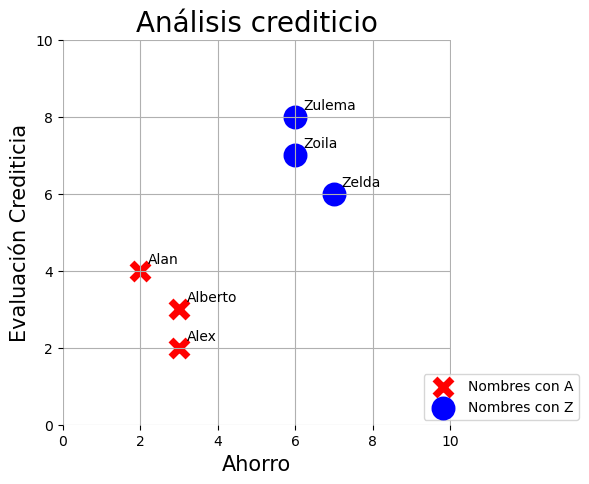

In [15]:
### EStablecemos el tamaño de la figura
plt.figure(figsize=(5, 5))

plt.title("Análisis crediticio", fontsize=20)

### Como la tabla esta acostada, la paramos y graficamos los puntos de las 3 filas (alan, alberto, alex)
plt.scatter(datos.T[0:3]["ahorro"], 
            datos.T[0:3]["evaluacion"], 
            marker="x", s=150, color="red",
            linewidths=5, label="Nombres con A")
### Lo mismo, la paramos y graficamos los ultimos (zelda, zoila, zulema)
plt.scatter(datos.T[3:]["ahorro"], 
            datos.T[3:]["evaluacion"], 
            marker="o", s=150, color="blue",
            linewidths=5, label="Nombres con Z")

### Ahora si sacamos todos los nombres, ya que .T no afecta el orden.
for nombre in datos.columns:
    ahorro = datos.loc["ahorro", nombre]
    evaluacion = datos.loc["evaluacion", nombre]
    ### Cerca de cada punto graficamos el nombre y lo capitalizamos
    plt.text(ahorro + 0.2, evaluacion + 0.2, nombre.capitalize()) 
    
plt.xlabel("Ahorro", fontsize=15)
plt.ylabel("Evaluación Crediticia", fontsize=15)
plt.legend(bbox_to_anchor=(1.35, 0.15))
plt.box(False)
plt.xlim((0, 10.01))
plt.ylim((0, 10.01))
plt.grid()
plt.show()

### Matrices para la Propagación de Afinidad

* Para empezar a hacer el algoritmo debemos empezar a calcular las siguientes matrices.
* `s -> Matriz Similitud (Entrada)`: Matriz que guarda la similutudes entre puntos, necesia todos los datos de entrada
* `r -> Matriz Responsabilidad`: Matriz con todos los puntos de admiración de cada nodo hacía los otros.
* `d -> Matriz Disponibilidad`: Matriz con todos los puntos de confianza de cada nodo contra los otros nodos.
* `a -> Matriz Asignaciones (Salida)`: Dada la matriz r y d, calculamos y asignamos donde pertenece cada nodo.

* Primero debemos empezar a calcular la matriz de similitud.

### Similitud entre dos puntos i, k

* La métrica para calcular la similitud ente 2 puntos por defecto se usa la `Distancia euclidiana al cuadrado`.
* Es decir la resta de 2 puntos al cuadrado pero  en este caso sin sacarle raiz, esto ayuda a penalizar más las grandes distancias y mejorar más las ditancias pequeñas.
* Ente caso cada columna representa una persona, X es el ahorro y Y es la evaluación.
* `datos["alan"] - datos["alberto"]`, nos dará ahorro -1 y evaluación 1.
* Al cuadrado dan 1,1, que suamos darán 2 y por el negativo -2.

In [16]:
print("\n", datos,"\n")
print("Similitud entre Alan y Alberto", -((datos["alan"] - datos["alberto"])**2).sum())
print("Similitud entre Alan y Zulema", -((datos["alan"] - datos["zulema"])**2).sum())


             alan  alberto  alex  zelda  zoila  zulema
ahorro         2        3     3      7      6       6
evaluacion     4        3     2      6      7       8 

Similitud entre Alan y Alberto -2
Similitud entre Alan y Zulema -32


### Creación de Matriz de Similitud para i != k

* Notese como la diagonal es de ceros, ya que la distancia es cero del Nodo A a A es cero.
* El detalle que la diagonal esté en ceros, que le puede dar preferencia a algunos nodos.
* El ciclo for es la misma operación anterior pero aplicada para todos los datos

In [27]:
s = pd.DataFrame(0, columns=datos.columns, index=datos.columns) 

for i in personas:
    for k in personas:
        s.loc[i, k] = -((datos[i] - datos[k])**2).sum()
s

,alan,alberto,alex,zelda,zoila,zulema
alan,0,-2,-5,-29,-25,-32
alberto,-2,0,-1,-25,-25,-34
alex,-5,-1,0,-32,-34,-45
zelda,-29,-25,-32,0,-2,-5
zoila,-25,-25,-34,-2,0,-1
zulema,-32,-34,-45,-5,-1,0


### Preferencia a priori de cada punto como Ejemplar

* Por el detalle de la preferencia asignamos el valor menor para que inclusive se fuercen más para que realmente se ganen el valor.
* Al estár maximizando, buscamos que el valor esté lo más cercano al cero posible.
* Aunque como negocio, podemos establecer preferencias como `el cliente ideal` con el atributo `preference`, para este caso todos serán tomados por igual.
* Todos la preferencia minima de -45.

In [19]:
np.fill_diagonal(s.values, np.min(s.values))

s

,alan,alberto,alex,zelda,zoila,zulema
alan,-45,-2,-5,-29,-25,-32
alberto,-2,-45,-1,-25,-25,-34
alex,-5,-1,-45,-32,-34,-45
zelda,-29,-25,-32,-45,-2,-5
zoila,-25,-25,-34,-2,-45,-1
zulema,-32,-34,-45,-5,-1,-45


### Matriz Mensajes de Disponibilidad

* Evidencia de qué tan adecuado es el emisor como Ejemplar
* Tenemos que llenarla de ceros, para que aun no haya candidatos a proponerse como el mayor ejemplar.
* Es importante inicializarla en ceros.

In [20]:
# Matriz de Disponibilidad
d = pd.DataFrame(0, columns=datos.columns, index=datos.columns) 

d

,alan,alberto,alex,zelda,zoila,zulema
alan,0,0,0,0,0,0
alberto,0,0,0,0,0,0
alex,0,0,0,0,0,0
zelda,0,0,0,0,0,0
zoila,0,0,0,0,0,0
zulema,0,0,0,0,0,0


### Matriz de Mensajes de Responsabilidad

* Evidencia de qué tan adecuado es el receptor como Ejemplar
* ***La responsabilidad se actualiza a partir de la similitud y la disponibilidad, es decir las matrices `s` y `d`***

In [28]:
# Responsabilidad ["alan", "alberto"]

sim = s.loc["alan", "alberto"]

sim_otros = s.loc["alan", ["alan", "alex", "zelda", "zoila", "zulema"]]

dis_otros = d.loc["alan", ["alan", "alex", "zelda", "zoila", "zulema"]]

print("Qué tan adecuado es Alberto como EJEMPLAR para Alan:", sim - max(sim_otros + dis_otros)) 


sim = s.loc["alan", "zulema"]

sim_otros = s.loc["alan", ["alan", "alberto", "alex", "zelda", "zoila"]]

dis_otros = d.loc["alan", ["alan", "alberto", "alex", "zelda", "zoila"]]

# Responsabilidad ["alan", "zulema"]

print("Qué tan adecuada es Zulema como EJEMPLAR para Alan:", sim - max(sim_otros + dis_otros)) 

Qué tan adecuado es Alberto como EJEMPLAR para Alan: -10.548239707946777
Qué tan adecuada es Zulema como EJEMPLAR para Alan: -40.54823970794678


### Algoritmo Principal - Actualización de Matrices:

* r : Responsabilidad
* d : Disponibilidad
* a : Asignaciones

* Armamos las asignaciones sobre cada ciclo.

In [23]:
# Matriz de Responsabilidad
r = pd.DataFrame(0, columns=datos.columns, index=datos.columns) 


for i in range(10):

    factor = 0.5

    # Actualización de Responsabilidades
    
    r_anterior = r.copy()

    for i in personas:
        for k in personas:
            elegibles = list(personas.difference({k}))
            r.loc[i, k] = s.loc[i, k] - max(s.loc[i, elegibles] + d.loc[i, elegibles])  
    
    r = (1 - factor)*r + factor*r_anterior
    

    # Actualización de Disponibilidades
    
    d_anterior = d.copy()

    for i in personas:
        for k in personas:
            if i == k:
                elegibles = list(personas.difference({i}))
                d.loc[k, k] = r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum()
            else:
                elegibles = list(personas.difference({i, k}))
                d.loc[i, k] = min(0, r.loc[k, k] + r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum())

    d = (1 - factor)*d + factor*d_anterior
    
    # Actualización de Asignaciones 
    
    a = r + d

C:\Users\PC\AppData\Local\Temp\ipykernel_14512\3416864372.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[k, k] = r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_14512\3416864372.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-21.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[i, k] = min(0, r.loc[k, k] + r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum())
C:\Users\PC\AppData\Local\Temp\ipykernel_14512\3416864372.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-18.5' has dtype incompatible with int64, please explicitly cast to a compat

### Matriz de Asignaciones

In [29]:
np.set_printoptions(precision=2)
print("Máximos", a.max(1).values) 
print("Posición de los máximos", np.argmax(a.values, axis=1))
a.round(decimals=2)

Máximos [21.63 25.59 26.4  21.63 25.59 26.4 ]
Posición de los máximos [1 1 1 4 4 4]


,alan,alberto,alex,zelda,zoila,zulema
alan,-31.67,21.63,-30.44,-54.04,-20.28,-55.87
alberto,-32.36,25.59,-31.23,-48.59,-18.82,-56.41
alex,-31.62,26.40,-30.64,-56.80,-29.03,-68.62
zelda,-54.04,-20.28,-55.87,-31.67,21.63,-30.44
zoila,-48.59,-18.82,-56.41,-32.36,25.59,-31.23
zulema,-56.80,-29.03,-68.62,-31.62,26.40,-30.64


### Propagación de afinidad con Scikit-Learn

* `Índices de Centroides: [1 4]`: el elemento 1 (Alberto) y el elemento 4 (zoila) son los centroides.
* `Etiquetas de Clusters: [0 0 0 1 1 1]`: a que cluster pertenecen cada uno.

In [25]:
clustering = AffinityPropagation(random_state=None).fit(datos.T.values)
print("Etiquetas de Clusters:", clustering.labels_)
print("Índices de Centroides:", clustering.cluster_centers_indices_)

Etiquetas de Clusters: [0 0 0 1 1 1]
Índices de Centroides: [1 4]
